In [60]:
# Run once to make sure everything is installed
# You can skip this cell if your environment is already set up
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'requests', 'pandas', 'nltk'])

0

In [61]:
import requests
import json
import re
import time
import pandas as pd

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer


In [62]:
# ---------------Configuration

# Steam App IDs for popular games (change or add more as needed)
# Find an app ID by visiting a store page: store.steampowered.com/app/{appid}
GAME_IDS = {
    730:   'Counter-Strike 2',
    570:   'Dota 2',
    1091500: 'Cyberpunk 2077',
}

MAX_REVIEWS_PER_GAME = 500
REVIEWS_PER_REQUEST  = 100
DELAY_BETWEEN_CALLS  = 1.0   # seconds - be polite to the API
OUTPUT_CSV           = 'steam_reviews_raw.csv'

In [63]:
def fetch_reviews_for_game(appid: int, game_name: str, max_reviews: int = 500) -> list[dict]:
    """
    Fetches up to `max_reviews` reviews for a Steam game using cursor-based pagination.

    Returns a list of dicts, each containing:
        review_text, voted_up, timestamp_created, appid, game_name
    """
    base_url = f'https://store.steampowered.com/appreviews/{appid}'
    params = {
        'json':           1,
        'language':       'english',
        'review_type':    'all',        # 'positive', 'negative', 'all'
        'purchase_type':  'all',
        'num_per_page':   REVIEWS_PER_REQUEST,
        'cursor':         '*',          # start cursor - Steam uses '*' for first page
        'filter':         'all',     # 'recent','updated', 'all'
    }

    collected = []
    seen_cursors = set()

    while len(collected) < max_reviews:
        try:
            response = requests.get(base_url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
        except requests.RequestException as e:
            print(f'   Request error for appid {appid}: {e}')
            break

        if data.get('success') != 1:
            print(f'   API returned success=0 for appid {appid}')
            break

        reviews = data.get('reviews', [])
        if not reviews:
            print(f'   No more reviews available for {game_name}.')
            break

        for r in reviews:
            collected.append({
                'review_text':       r.get('review', ''),
                'voted_up':          r.get('voted_up', None),       # True = recommended
                'timestamp_created': r.get('timestamp_created', None),
                'appid':             appid,
                'game_name':         game_name,
            })

        new_cursor = data.get('cursor', '')
        print(f'  Fetched {len(collected):>4} reviews so far for {game_name}...')

        # Stop if cursor hasn't changed (end of results)
        if new_cursor in seen_cursors or new_cursor == params['cursor']:
            print(f'  [✓] Cursor loop detected - stopping for {game_name}.')
            break

        seen_cursors.add(new_cursor)
        params['cursor'] = new_cursor
        time.sleep(DELAY_BETWEEN_CALLS)

    return collected[:max_reviews]

In [64]:
# --------------- Collect reviews for all configured games
all_reviews = []

for appid, name in GAME_IDS.items():
    print(f'\nFetching reviews for: {name} (appid={appid})')
    reviews = fetch_reviews_for_game(appid, name, max_reviews=MAX_REVIEWS_PER_GAME)
    all_reviews.extend(reviews)
    print(f'  Done. Total reviews collected so far: {len(all_reviews)}')

print(f'\nTotal reviews collected: {len(all_reviews)}')


Fetching reviews for: Counter-Strike 2 (appid=730)
  Fetched  100 reviews so far for Counter-Strike 2...
  Fetched  200 reviews so far for Counter-Strike 2...
  Fetched  300 reviews so far for Counter-Strike 2...
  Fetched  400 reviews so far for Counter-Strike 2...
  Fetched  500 reviews so far for Counter-Strike 2...
  Done. Total reviews collected so far: 500

Fetching reviews for: Dota 2 (appid=570)
  Fetched  100 reviews so far for Dota 2...
  Fetched  200 reviews so far for Dota 2...
  Fetched  300 reviews so far for Dota 2...
  Fetched  400 reviews so far for Dota 2...
  Fetched  500 reviews so far for Dota 2...
  Done. Total reviews collected so far: 1000

Fetching reviews for: Cyberpunk 2077 (appid=1091500)
  Fetched  100 reviews so far for Cyberpunk 2077...
  Fetched  200 reviews so far for Cyberpunk 2077...
  Fetched  300 reviews so far for Cyberpunk 2077...
  Fetched  400 reviews so far for Cyberpunk 2077...
  Fetched  500 reviews so far for Cyberpunk 2077...
  Done. Total

In [65]:
# ------------- Convert to DataFrame and inspect
df_raw = pd.DataFrame(all_reviews)

# Convert Unix timestamp to a readable datetime
df_raw['date'] = pd.to_datetime(df_raw['timestamp_created'], unit='s', errors='coerce')

print(f'Shape: {df_raw.shape}')
print(f'\nSentiment distribution:')
print(df_raw['voted_up'].value_counts().rename({True: 'Positive reviews', False: 'Negative reviews'}).to_string())
print(f'\nReviews per game:')
print(df_raw['game_name'].value_counts().to_string())

df_raw.head(3)

Shape: (1500, 6)

Sentiment distribution:
voted_up
Positive reviews    1089
Negative reviews     411

Reviews per game:
game_name
Counter-Strike 2    500
Dota 2              500
Cyberpunk 2077      500


,review_text,voted_up,timestamp_created,appid,game_name,date
0,You play well = cheater\nYou play badly = noob\nYou get a headshot = cheater\nYou hear info and can more or less nav...,True,1775462390,730,Counter-Strike 2,2026-04-06 07:59:50
1,10/10 game\r\n\r\n• teammates call you bot\r\n• enemies call you cheater\r\n• you miss the easiest shots\r\n• you hi...,True,1775492264,730,Counter-Strike 2,2026-04-06 16:17:44
2,"Installed for fun. Stayed for the trauma.\n\nMissed easy shots, got one tapped by a guy I never saw, Sometimes you p...",True,1775030502,730,Counter-Strike 2,2026-04-01 08:01:42


In [66]:
# ----------- Drop rows with empty review text
before = len(df_raw)
df_raw = df_raw[df_raw['review_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Removed {before - len(df_raw)} empty reviews. Remaining: {len(df_raw)}')

Removed 0 empty reviews. Remaining: 1500


In [67]:
# ----------- Save raw dataset
df_raw.to_csv(OUTPUT_CSV, index=False)
print(f'Raw dataset saved to: {OUTPUT_CSV}')

Raw dataset saved to: steam_reviews_raw.csv


In [68]:
#  Load from CSV (skip this cell if df_raw is already in memory)
# df_raw = pd.read_csv('steam_reviews_raw.csv')
# df_raw['date'] = pd.to_datetime(df_raw['date'], errors='coerce')
# print(f'Loaded {len(df_raw)} reviews from CSV.')

In [69]:
# ------------- Stopwords list
STOP_WORDS = set(stopwords.words('english'))

# Optional: add game-specific noise words that add no signal
CUSTOM_STOPWORDS = {'game', 'games', 'play', 'played', 'player', 'steam',
                    'get', 'got', 'one', 'would', 'really', 'also', 'like'}
STOP_WORDS.update(CUSTOM_STOPWORDS)

print(f'Total stopwords: {len(STOP_WORDS)}')

Total stopwords: 211


In [70]:
def preprocess_review(text: str) -> str:
    """
    Clean a raw review string and return a preprocessed string of tokens.
    Steps:
        1. Lowercase
        2. Strip URLs
        3. Remove non-ASCII characters
        4. Remove punctuation and digits
        5. Tokenize
        6. Remove stopwords and short tokens
        7. Join into a single clean string
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    #Lowercase
    text = text.lower()

    #Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    #Remove non-ASCII (emoji, foreign chars)
    text = text.encode('ascii', errors='ignore').decode()

    #Remove punctuation and digits -keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    #Remove stopwords and very short tokens
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

    # 7. Rejoin
    return ' '.join(tokens)

In [71]:
# --------------- Quick sanity check
sample = "10/10 would NOT recommend!!!!! The game crashed 5 times. https://store.steam.com"
print('Before:', sample)
print('After: ', preprocess_review(sample))

Before: 10/10 would NOT recommend!!!!! The game crashed 5 times. https://store.steam.com
After:  recommend crashed times


In [72]:
#--------------- Apply preprocessing to entire dataset
print('Preprocessing reviews....(this may take time)')

df_raw['review_clean'] = df_raw['review_text'].apply(preprocess_review)

# Drop rows where preprocessing produced an empty string
before = len(df_raw)
df_clean = df_raw[df_raw['review_clean'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Dropped {before - len(df_clean)} empty rows after preprocessing.')
print(f'Final dataset shape: {df_clean.shape}')

Preprocessing reviews....(this may take time)
Dropped 37 empty rows after preprocessing.
Final dataset shape: (1463, 7)


In [73]:
# --------------- Preview some examples
pd.set_option('display.max_colwidth', 120)
df_clean[['review_text', 'review_clean', 'voted_up']].head(5)

,review_text,review_clean,voted_up
0,You play well = cheater\nYou play badly = noob\nYou get a headshot = cheater\nYou hear info and can more or less nav...,well cheater badly noob headshot cheater hear info less navigate map cheater kill someone cheater general,True
1,10/10 game\r\n\r\n• teammates call you bot\r\n• enemies call you cheater\r\n• you miss the easiest shots\r\n• you hi...,teammates call bot enemies call cheater miss easiest shots hit impossible ones hate see tomorrow,True
2,"Installed for fun. Stayed for the trauma.\n\nMissed easy shots, got one tapped by a guy I never saw, Sometimes you p...",installed fun stayed trauma missed easy shots tapped guy never saw sometimes well sometimes die without even knowing...,True
3,"Counter-Strike 2 - this isn’t a shooter, it’s a mental stability test. You go in as a normal person and come out wan...",counter strike isnt shooter mental stability test go normal person come wanting uninstall everything teammates every...,True
4,"this game will steal a part of your soul and make you a gambling addict, but you wont be able to stop...",steal part soul make gambling addict wont able stop,True


In [74]:
#-------------- Basic token statistics
df_clean['token_count'] = df_clean['review_clean'].str.split().str.len()

print('Token count statistics:')
print(df_clean['token_count'].describe().round(2).to_string())
print(f'\nReviews with < 5 tokens: {(df_clean["token_count"] < 5).sum()}')

Token count statistics:
count    1463.00
mean       27.68
std        48.37
min         1.00
25%         9.00
50%        14.00
75%        28.00
max       738.00

Reviews with < 5 tokens: 56


In [75]:
# --------------- Optional: filter out very short reviews
MIN_TOKENS = 5
before = len(df_clean)
df_clean = df_clean[df_clean['token_count'] >= MIN_TOKENS].reset_index(drop=True)
print(f'Kept {len(df_clean)} reviews with >= {MIN_TOKENS} tokens (removed {before - len(df_clean)}).')

Kept 1407 reviews with >= 5 tokens (removed 56).


In [76]:
# --------------- Save preprocessed dataset
CLEAN_CSV = 'steam_reviews_clean.csv'
df_clean.to_csv(CLEAN_CSV, index=False)
print(f'Preprocessed dataset saved to: {CLEAN_CSV}')
print(f'Columns: {list(df_clean.columns)}')

Preprocessed dataset saved to: steam_reviews_clean.csv
Columns: ['review_text', 'voted_up', 'timestamp_created', 'appid', 'game_name', 'date', 'review_clean', 'token_count']


In [77]:
from collections import Counter
import numpy as np

# -----------------------Calculate TF-IDF
# Load preprocessed reviews
df = pd.read_csv('steam_reviews_clean.csv')
valid_not_null = df['review_clean'].notna()
valid_not_empty = df['review_clean'].str.strip() != ''
df = df[valid_not_null & valid_not_empty].reset_index(drop=True)
corpus = [review.split() for review in df['review_clean']]
print(f'Documents : {len(corpus)}')
print(f'Example   : {corpus[0][:10]}')

# --- Build vocab
def build_vocabulary(corpus: list[list[str]]) -> dict[str, int]:
    """Maps each unique token to a column index (sorted for reproducibility)."""
    all_tokens = set()
    for doc in corpus:
        for token in doc:
            all_tokens.add(token)
    return {token: idx for idx, token in enumerate(sorted(all_tokens))}

vocab        = build_vocabulary(corpus)
idx_to_token = {v: k for k, v in vocab.items()}

print(f'Vocabulary size : {len(vocab):,} unique tokens')

# -- Compute TF matrix
def compute_tf_matrix(corpus: list[list[str]], vocab: dict[str, int]) -> np.ndarray:
    """Each cell [i, j] = raw count of vocab token j in document i."""
    tf = np.zeros((len(corpus), len(vocab)), dtype=np.float32)
    for doc_idx, doc in enumerate(corpus):
        for token, count in Counter(doc).items():
            if token in vocab:
                tf[doc_idx, vocab[token]] = count
    return tf


tf_matrix = compute_tf_matrix(corpus, vocab)
print(f'TF matrix shape : {tf_matrix.shape}')

# -- Compute IDF vector
# IDF(t) = log(N / df(t))
def compute_idf_vector(tf_matrix: np.ndarray) -> np.ndarray:
    """Standard IDF: log(N / df). Terms with df=0 get IDF=0."""
    N  = tf_matrix.shape[0]
    df = np.count_nonzero(tf_matrix, axis=0)
    return np.where(df > 0, np.log(N / df), 0.0).astype(np.float32)


idf_vector = compute_idf_vector(tf_matrix)

# Inspect: lowest and highest IDF terms
idx_sorted = np.argsort(idf_vector)
print('10 most common terms (lowest IDF):')
for i in idx_sorted[:10]:
    print(f'  {idx_to_token[i]:<20} idf = {idf_vector[i]:.4f}')
print('\n10 rarest terms (highest IDF):')
for i in idx_sorted[-10:][::-1]:
    print(f'  {idx_to_token[i]:<20} idf = {idf_vector[i]:.4f}')

# Compute TF- IDF and apply L2 normalization

def l2_normalize(matrix: np.ndarray) -> np.ndarray:
    """
    L2-normalizes each row so all vectors have unit length.
    Rows with zero norm (all-zero vectors) stay as zero - no division.
    """
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)  # shape (n_docs, 1)
    return np.where(norms > 0, matrix / norms, 0.0).astype(np.float32)


tfidf_matrix      = tf_matrix * idf_vector          # TF × IDF  (n_docs, vocab)
tfidf_matrix_l2   = l2_normalize(tfidf_matrix)      # L2 normalize each row

# Sanity check: all row norms should be ~1.0 (or 0 for empty docs)
row_norms = np.linalg.norm(tfidf_matrix_l2, axis=1)
print(f'TF-IDF L2 matrix shape : {tfidf_matrix_l2.shape}')
print(f'Row norm min/max       : {row_norms.min():.4f} / {row_norms.max():.4f}  (expect 0 or 1.0)')

# Save output
np.save('tfidf_matrix_l2.npy', tfidf_matrix_l2)
np.save('idf_vector.npy',      idf_vector)
pd.DataFrame(vocab.items(), columns=['token', 'index']).to_csv('vocabulary.csv', index=False)

print('Saved:')
print(f'  tfidf_matrix_l2.npy  {tfidf_matrix_l2.shape}')
print(f'  idf_vector.npy       {idf_vector.shape}')
print(f'  vocabulary.csv       {len(vocab)} tokens')

Documents : 1407
Example   : ['well', 'cheater', 'badly', 'noob', 'headshot', 'cheater', 'hear', 'info', 'less', 'navigate']
Vocabulary size : 7,865 unique tokens
TF matrix shape : (1407, 7865)
10 most common terms (lowest IDF):
  good                 idf = 1.6288
  time                 idf = 1.7812
  story                idf = 1.8647
  fun                  idf = 1.9711
  playing              idf = 2.0022
  even                 idf = 2.0022
  still                idf = 2.1253
  ever                 idf = 2.1312
  great                idf = 2.1555
  every                idf = 2.2123

10 rarest terms (highest IDF):
  aass                 idf = 7.2492
  zz                   idf = 7.2492
  abandons             idf = 7.2492
  zwyczajnie           idf = 7.2492
  absorbed             idf = 7.2492
  absorbs              idf = 7.2492
  absudity             idf = 7.2492
  absurdly             idf = 7.2492
  abundance            idf = 7.2492
  abused               idf = 7.2492
TF-IDF L2 matrix sh

In [78]:
# --------------------- Doing sentiment analysis through VADER
#download and intialize VADEr lexicon
nltk.download('vader_lexicon', quiet=True)

sia= SentimentIntensityAnalyzer()

# applying VADER to raw text reviews first
print ("computing VADER sentiment scores for raw reviews...")
df_clean ['vader_scores'] = df_clean['review_text'].apply(lambda x: sia.polarity_scores(x))

#get compound score 
df_clean['vader_compound'] = df_clean['vader_scores'].apply(lambda x: x['compound'])

# classify as positive, and negative based on the compound score from before (>=.05 positive, <=-.05 negative)
df_clean["vader_sentiment"] = df_clean['vader_compound'].apply(
    lambda x: 'positive' if x >= 0.05 else ('negative' if x <= -0.05 else 'neutral')
)

print(f'VADER sentiment distribution:\n {df_clean["vader_sentiment"].value_counts().to_string()}')

print(f'VADER vs steam Sentiment analysis labels')
comparison = pd.crosstab(df_clean['voted_up'], df_clean['vader_sentiment'], rownames=['Steam Sentiment'], colnames=['VADER Sentiment'])
print(comparison.to_string())

# extract individual scores into clean columns
df_clean['vader_neg'] = df_clean['vader_scores'].apply(lambda x: x['neg'])
df_clean['vader_neu'] = df_clean['vader_scores'].apply(lambda x: x['neu'])
df_clean['vader_pos'] = df_clean['vader_scores'].apply(lambda x: x['pos'])

# drop the raw dict column — dicts don't save cleanly to CSV
df_clean = df_clean.drop(columns=['vader_scores'])
df_clean.to_csv('steam_reviews_sentiment.csv', index=False)





computing VADER sentiment scores for raw reviews...
VADER sentiment distribution:
 vader_sentiment
positive    945
negative    398
neutral      64
VADER vs steam Sentiment analysis labels
VADER Sentiment  negative  neutral  positive
Steam Sentiment                             
False                 230       19       137
True                  168       45       808


Setup OK.
Rows   : 1407
Columns: ['review_text', 'voted_up', 'timestamp_created', 'appid', 'game_name', 'date', 'review_clean', 'token_count', 'vader_compound', 'vader_sentiment', 'vader_neg', 'vader_neu', 'vader_pos']


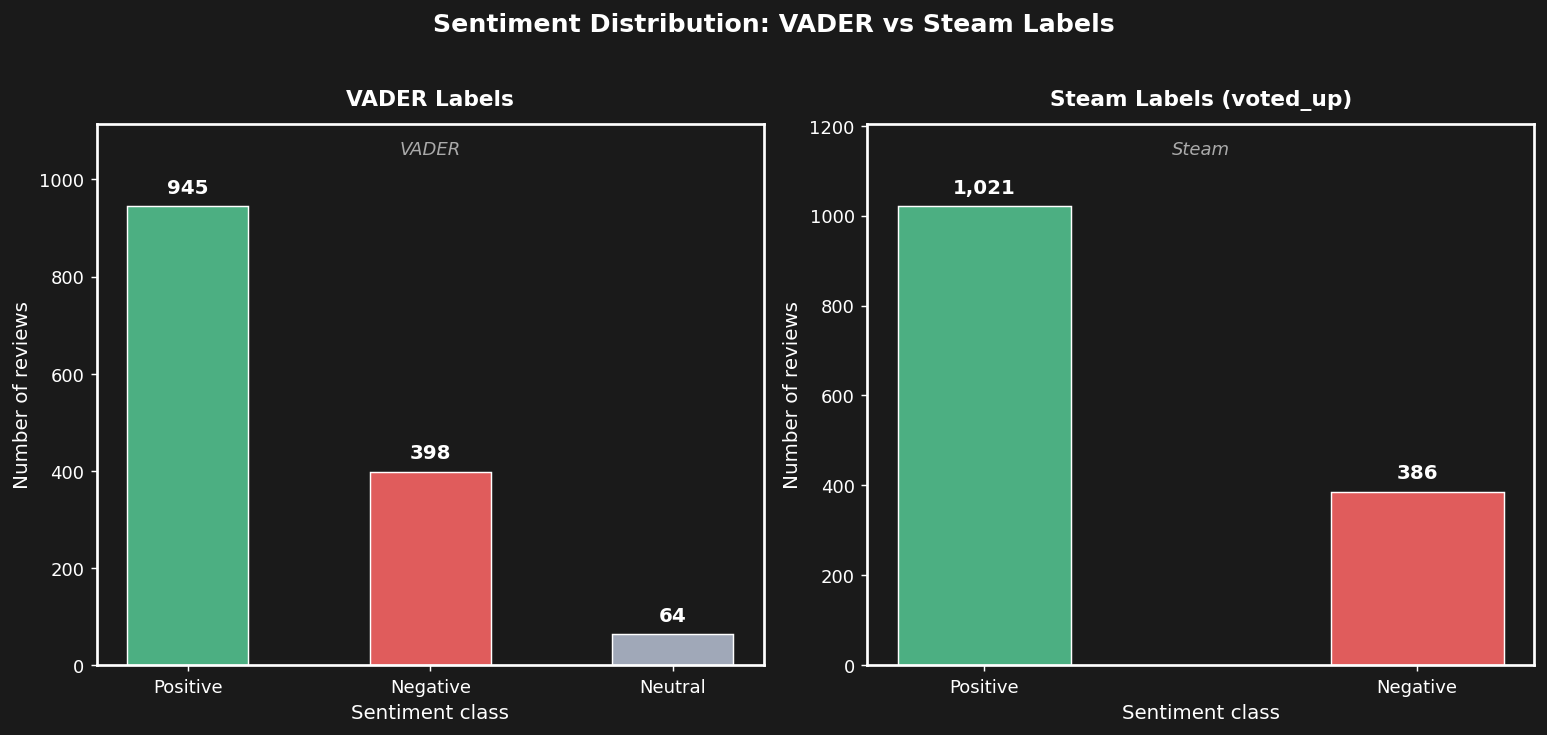

Saved: chart1_sentiment_distribution.png


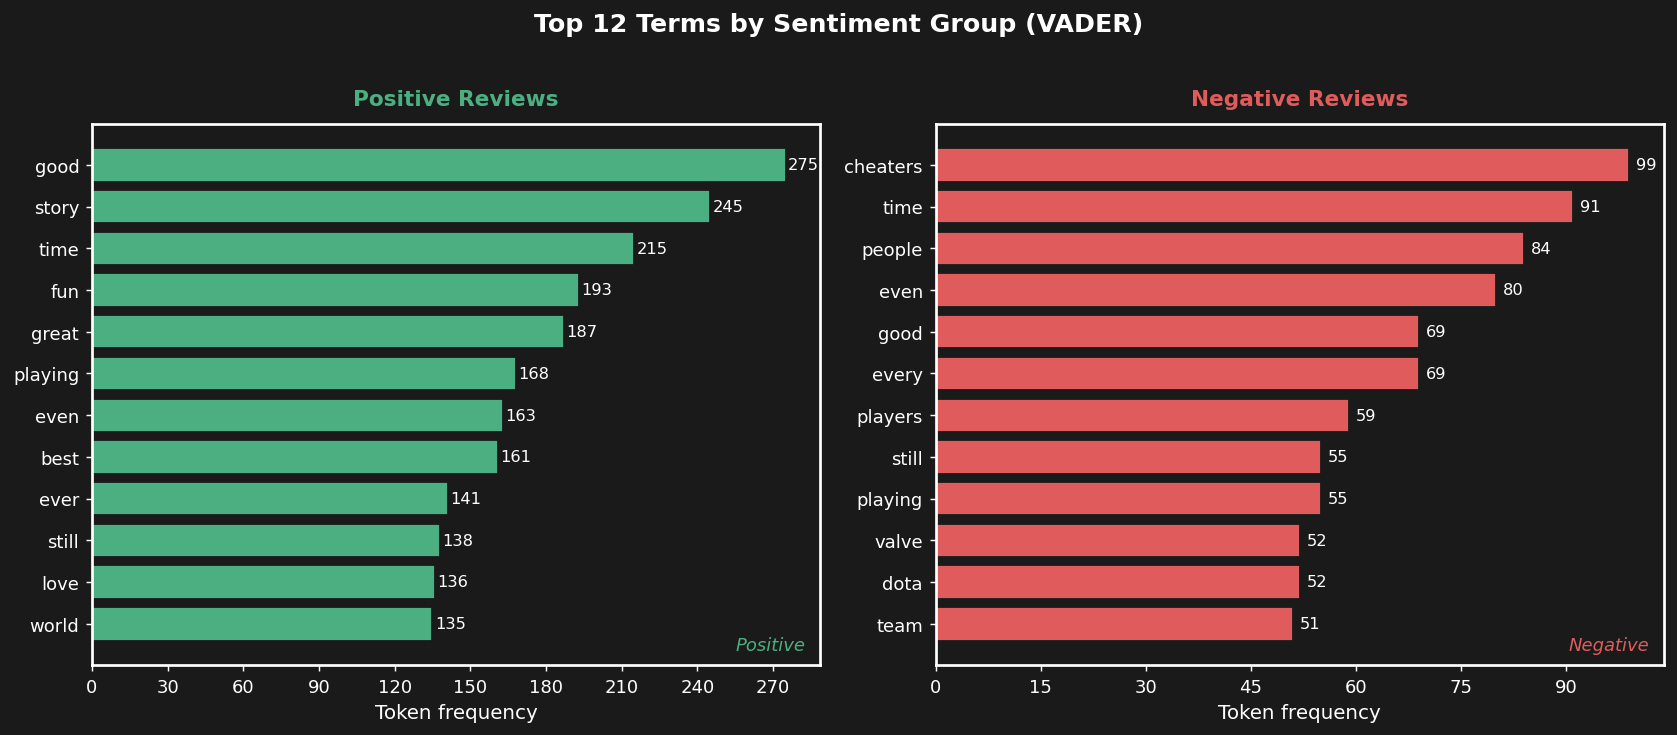

Saved: chart2_top_terms.png


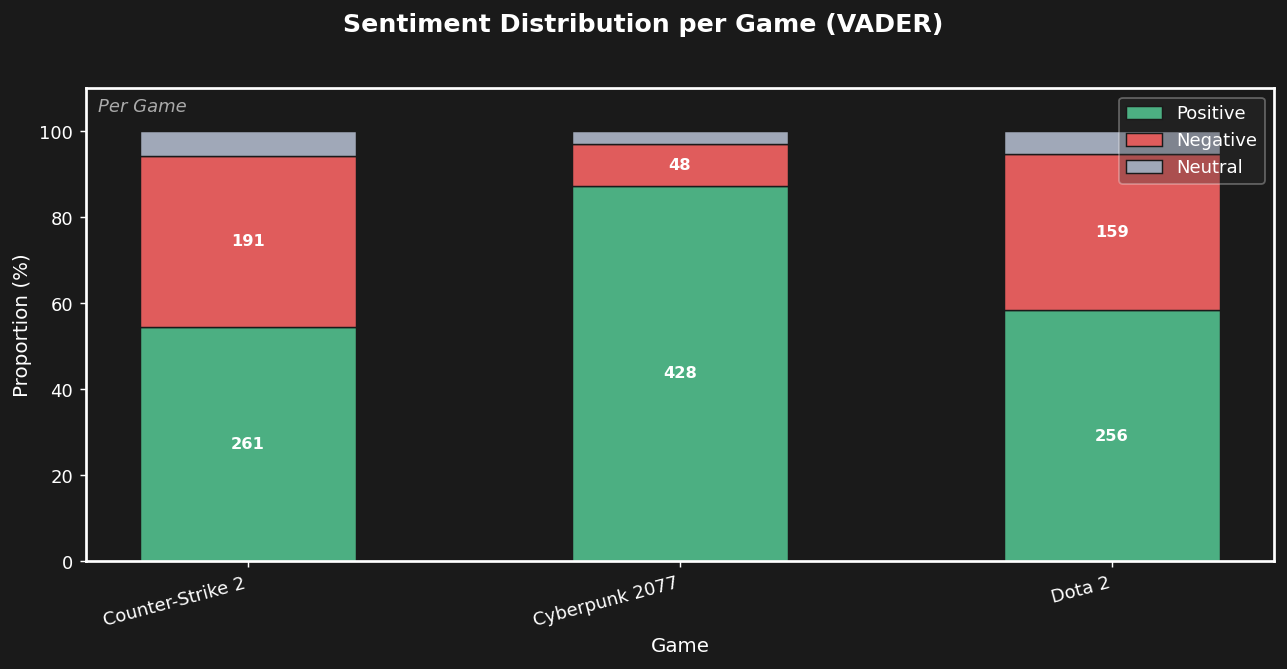

Saved: chart3_sentiment_per_game.png


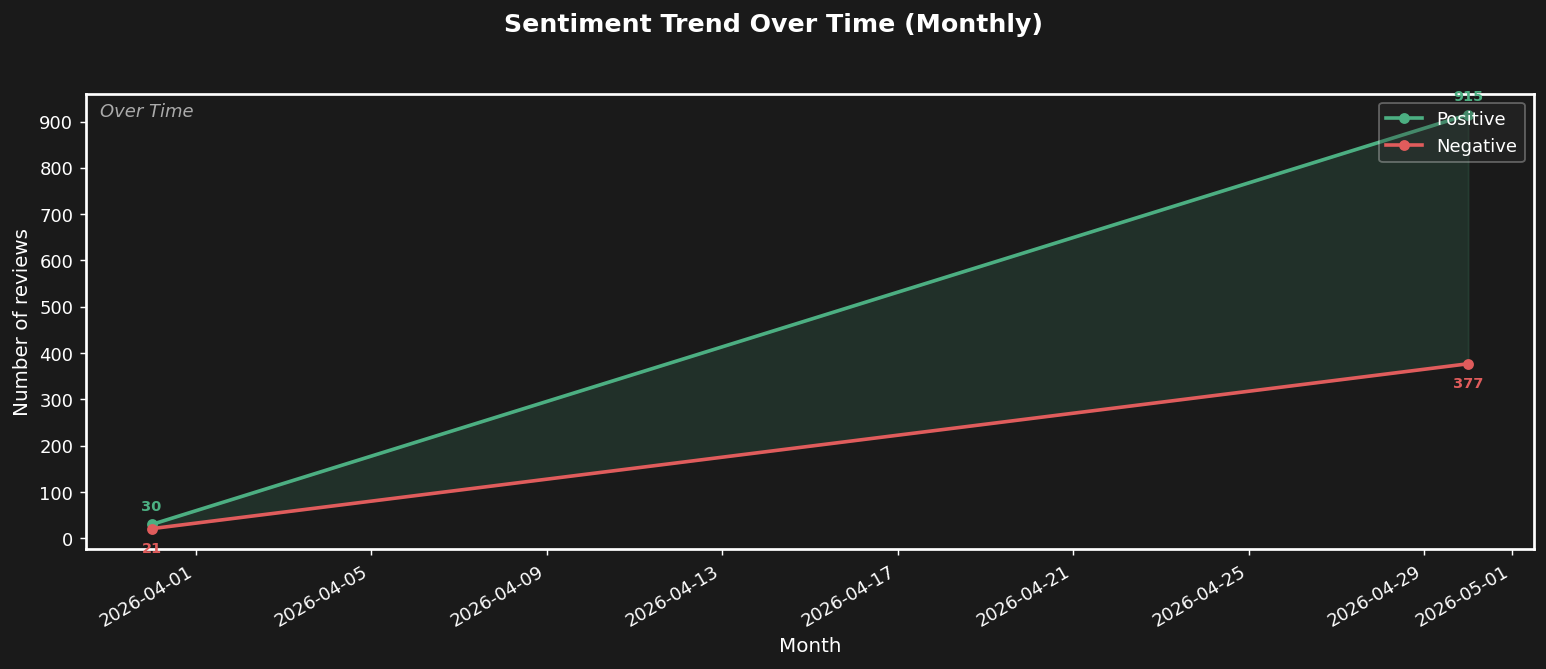

Saved: chart4_sentiment_over_time.png


In [87]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


# Consistent style across all charts
plt.rcParams.update({
    'figure.dpi':      130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize':  13,
    'axes.titleweight': 'bold',
    'axes.labelsize':  11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
})

# Color palette used throughout
C_POS     = '#4CAF82'   # green  — positive
C_NEG     = '#E05C5C'   # red    — negative
C_NEU     = '#A0A8B8'   # grey   — neutral
C_STEAM   = '#1A9FFF'   # blue   — Steam label

print('Setup OK.')
df = pd.read_csv('steam_reviews_sentiment.csv')
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print(f'Rows   : {len(df)}')
print(f'Columns: {list(df.columns)}')
######################## Chart 1 ############################################
# -- Count labels --------------
vader_counts = df['vader_sentiment'].value_counts().reindex(['positive', 'negative', 'neutral'], fill_value=0)
steam_counts = df['voted_up'].astype(bool).map({True: 'positive', False: 'negative'}).value_counts().reindex(['positive', 'negative'], fill_value=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), facecolor='#1a1a1a')
ax1.set_facecolor('#1a1a1a')
ax2.set_facecolor('#1a1a1a')

fig.suptitle('Sentiment Distribution: VADER vs Steam Labels',
             fontsize=14, fontweight='bold', color='white', y=1.02)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
        spine.set_linewidth(1.5)
        spine.set_visible(True)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# -- Left: VADER ---------------------------------------------------------------
labels1 = ['Positive', 'Negative', 'Neutral']
bars1   = ax1.bar(labels1, vader_counts.values,
                  color=[C_POS, C_NEG, C_NEU], edgecolor='white', linewidth=0.8, width=0.5)
ax1.set_title('VADER Labels', fontsize=12, pad=10)
ax1.set_ylabel('Number of reviews')
ax1.set_xlabel('Sentiment class')
ax1.set_ylim(0, vader_counts.max() * 1.18)

# count + "VADER" label on the chart
ax1.text(0.5, 0.97, 'VADER', transform=ax1.transAxes,
         ha='center', va='top', fontsize=10, color='#aaaaaa',
         fontstyle='italic')
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + vader_counts.max() * 0.02,
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')

# -- Right: Steam --------------------------------------------------------------
labels2 = ['Positive', 'Negative']
bars2   = ax2.bar(labels2, steam_counts.values,
                  color=[C_POS, C_NEG], edgecolor='white', linewidth=0.8, width=0.4)
ax2.set_title('Steam Labels (voted_up)', fontsize=12, pad=10)
ax2.set_ylabel('Number of reviews')
ax2.set_xlabel('Sentiment class')
ax2.set_ylim(0, steam_counts.max() * 1.18)

# count + "Steam" label on the chart
ax2.text(0.5, 0.97, 'Steam', transform=ax2.transAxes,
         ha='center', va='top', fontsize=10, color='#aaaaaa',
         fontstyle='italic')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + steam_counts.max() * 0.02,
             f'{int(bar.get_height()):,}',
             ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('chart1_sentiment_distribution.png', bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
print('Saved: chart1_sentiment_distribution.png')

############################################## CHART 2 ##########################################

TOP_N = 12   # how many terms to show per group
def top_terms(df_group: pd.DataFrame, n: int = TOP_N) -> tuple[list, list]:
    """Returns (terms, counts) for the n most frequent tokens in review_clean."""
    all_tokens = ' '.join(df_group['review_clean'].dropna()).split()
    most_common = Counter(all_tokens).most_common(n)
    terms  = [t for t, _ in most_common]
    counts = [c for _, c in most_common]
    return terms, counts


pos_terms, pos_counts = top_terms(df[df['vader_sentiment'] == 'positive'])
neg_terms, neg_counts = top_terms(df[df['vader_sentiment'] == 'negative'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), facecolor='#1a1a1a')
ax1.set_facecolor('#1a1a1a')
ax2.set_facecolor('#1a1a1a')
fig.suptitle(f'Top {TOP_N} Terms by Sentiment Group (VADER)',
             fontsize=14, fontweight='bold', color='white', y=1.02)

for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_edgecolor('white')
        spine.set_linewidth(1.5)
        spine.set_visible(True)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# -- Positive ------------------------------------------------------------------
ax1.barh(pos_terms[::-1], pos_counts[::-1], color=C_POS, edgecolor='#1a1a1a')
for i, (term, count) in enumerate(zip(pos_terms[::-1], pos_counts[::-1])):
    ax1.text(count + 1, i, f'{count:,}',
             va='center', fontsize=9, color='white')
ax1.set_title('Positive Reviews', fontsize=12, pad=10, color=C_POS)
ax1.set_xlabel('Token frequency')
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.text(0.98, 0.02, 'Positive', transform=ax1.transAxes,
         ha='right', va='bottom', fontsize=10, color=C_POS, fontstyle='italic')

# -- Negative ------------------------------------------------------------------
ax2.barh(neg_terms[::-1], neg_counts[::-1], color=C_NEG, edgecolor='#1a1a1a')
for i, (term, count) in enumerate(zip(neg_terms[::-1], neg_counts[::-1])):
    ax2.text(count + 1, i, f'{count:,}',
             va='center', fontsize=9, color='white')
ax2.set_title('Negative Reviews', fontsize=12, pad=10, color=C_NEG)
ax2.set_xlabel('Token frequency')
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.text(0.98, 0.02, 'Negative', transform=ax2.transAxes,
         ha='right', va='bottom', fontsize=10, color=C_NEG, fontstyle='italic')

plt.tight_layout()
plt.savefig('chart2_top_terms.png', bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
print('Saved: chart2_top_terms.png')
############################# CHART 3 ####################################
#Pergame
# -- Build proportion table ----
game_sentiment = (
    df.groupby(['game_name', 'vader_sentiment'])
      .size()
      .unstack(fill_value=0)
      .reindex(columns=['positive', 'negative', 'neutral'], fill_value=0)
)
game_props = game_sentiment.div(game_sentiment.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')
fig.suptitle('Sentiment Distribution per Game (VADER)',
             fontsize=14, fontweight='bold', color='white', y=1.02)

for spine in ax.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(1.5)
    spine.set_visible(True)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

x      = np.arange(len(game_props))
width  = 0.5
bottom = np.zeros(len(game_props))

for label, color in [('positive', C_POS), ('negative', C_NEG), ('neutral', C_NEU)]:
    vals       = game_props[label].values
    counts_raw = game_sentiment[label].values
    bars       = ax.bar(x, vals, width, bottom=bottom, label=label.capitalize(),
                        color=color, edgecolor='#1a1a1a', linewidth=0.8)
    for bar, val, raw, bot in zip(bars, vals, counts_raw, bottom):
        if val > 8:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2,
                    f'{int(raw)}',
                    ha='center', va='center', fontsize=9,
                    color='white', fontweight='bold')
    bottom += vals

# "Per Game" label on chart
ax.text(0.01, 0.98, 'Per Game', transform=ax.transAxes,
        ha='left', va='top', fontsize=10, color='#aaaaaa', fontstyle='italic')

ax.set_ylabel('Proportion (%)')
ax.set_xlabel('Game')
ax.set_xticks(x)
ax.set_xticklabels(game_props.index, rotation=15, ha='right', color='white')
ax.set_ylim(0, 110)
legend = ax.legend(loc='upper right', framealpha=0.3,
                   facecolor='#333333', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.savefig('chart3_sentiment_per_game.png', bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
print('Saved: chart3_sentiment_per_game.png')
####################################### Chart 4 ########################################
# -- Resample to monthly counts
df_time = df[df['date'].notna() & (df['vader_sentiment'] != 'neutral')].copy()
df_time = df_time.set_index('date')

monthly = (
    df_time.groupby([pd.Grouper(freq='ME'), 'vader_sentiment'])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=['positive', 'negative'], fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')
fig.suptitle('Sentiment Trend Over Time (Monthly)',
             fontsize=14, fontweight='bold', color='white', y=1.02)

for spine in ax.spines.values():
    spine.set_edgecolor('white')
    spine.set_linewidth(1.5)
    spine.set_visible(True)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')

ax.plot(monthly.index, monthly['positive'], color=C_POS, linewidth=2,
        marker='o', markersize=5, label='Positive')
ax.plot(monthly.index, monthly['negative'], color=C_NEG, linewidth=2,
        marker='o', markersize=5, label='Negative')

# fill between lines
ax.fill_between(monthly.index,
                monthly['positive'], monthly['negative'],
                where=monthly['positive'] >= monthly['negative'],
                alpha=0.15, color=C_POS, label='_nolegend_')
ax.fill_between(monthly.index,
                monthly['positive'], monthly['negative'],
                where=monthly['positive'] < monthly['negative'],
                alpha=0.15, color=C_NEG, label='_nolegend_')

# count labels on each data point
for date, val in monthly['positive'].items():
    if val > 0:
        ax.annotate(f'{int(val)}', (date, val),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8, color=C_POS, fontweight='bold')

for date, val in monthly['negative'].items():
    if val > 0:
        ax.annotate(f'{int(val)}', (date, val),
                    textcoords='offset points', xytext=(0, -13),
                    ha='center', fontsize=8, color=C_NEG, fontweight='bold')

# "Over Time" label on chart
ax.text(0.01, 0.98, 'Over Time', transform=ax.transAxes,
        ha='left', va='top', fontsize=10, color='#aaaaaa', fontstyle='italic')

ax.set_ylabel('Number of reviews')
ax.set_xlabel('Month')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

legend = ax.legend(loc='upper right', framealpha=0.3,
                   facecolor='#333333', edgecolor='white', labelcolor='white')

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.savefig('chart4_sentiment_over_time.png', bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
print('Saved: chart4_sentiment_over_time.png')

In [80]:
# Setup for Logiscitic regression with TF-IDF features
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

#loading the TF-IDF features and labels
tfidf_matrix_12 = np.load('tfidf_matrix_l2.npy')
X = tfidf_matrix_12
y = df_clean['voted_up'].values.astype(int)  # converts boolean to int

#data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'training set: {X_train.shape[0]}, reviews')
print(f"test set: {X_test.shape[0]}, reviews")
print (f'features: {X_train.shape[1]}')

training set: 1125, reviews
test set: 282, reviews
features: 7865


In [81]:
# Logistic Regression model
class LogisticRegressionModel:
    def __init__ (self, LRate=0.01, max_iter=1000):
        self.LRate = LRate
        self.max_iter = max_iter
        self.weights= None
        self.bias = None
        self.costs =[]

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def calculate_cost (self, theta, X, y):
        m = len(y)
        h_theta = self.sigmoid(X.dot(theta))
        term1 = np.dot(y.T, np.log(h_theta))
        term2 = np.dot((1 - y).T, np.log(1 - h_theta + 1e-15))
        J = -1 / m* (term1 + term2)
        return J

    def calculate_gradient(self, theta, X, y):
        m = len(y)
        h_theta = self.sigmoid(X.dot(theta))
        grad = 1 / m * X.T.dot(h_theta - y)
        return grad

    def fit(self, X, y):
        #compute gradiuents and update weights
        X = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)  #add bias

        self.theta = np.zeros(X.shape[1])  # Initialize theta

        print(f"initial cost: {self.calculate_cost(self.theta, X, y):.6f}")

        # Gradient descent
        for i in range(self.max_iter):
            grad = self.calculate_gradient(self.theta, X, y)
            self.theta -= self.LRate * grad
            cost = self.calculate_cost(self.theta, X, y)
            self.costs.append(cost)

            if i % 100 == 0:
                print(f"iteration {i+1}/ {self.max_iter}, cost: {cost:.6f}")

    def predict_proba(self, X):
        "predicting probabulities"
        X = np.concatenate([np.ones((X.shape[0], 1)), X], axis=1)
        return self.sigmoid(X.dot(self.theta))

    def predict(self, X, threshold=0.5):
        "predicting binary labels based on threshold"
        return (self.predict_proba(X) >= threshold).astype(int)


In [82]:
# train and evaluate the model

lr_model = LogisticRegressionModel(LRate=0.1, max_iter=500)
lr_model.fit(X_train, y_train)

#prediuctions
y_pred = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Logistic Regression Accuracy: {accuracy:.4f}')
print (f"classification report:\n {classification_report(y_test, y_pred, target_names=['Negative', 'Positive'])}")

initial cost: 0.693147
iteration 1/ 500, cost: 0.688207
iteration 101/ 500, cost: 0.587702
iteration 201/ 500, cost: 0.581561
iteration 301/ 500, cost: 0.576548
iteration 401/ 500, cost: 0.571648
Logistic Regression Accuracy: 0.7447
classification report:
               precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        72
    Positive       0.74      1.00      0.85       210

    accuracy                           0.74       282
   macro avg       0.37      0.50      0.43       282
weighted avg       0.55      0.74      0.64       282



E:\C-Relocation\Desktop\KU\EECS 767\767-Steam-Sentiment-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\C-Relocation\Desktop\KU\EECS 767\767-Steam-Sentiment-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
E:\C-Relocation\Desktop\KU\EECS 767\767-Steam-Sentiment-analysis\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

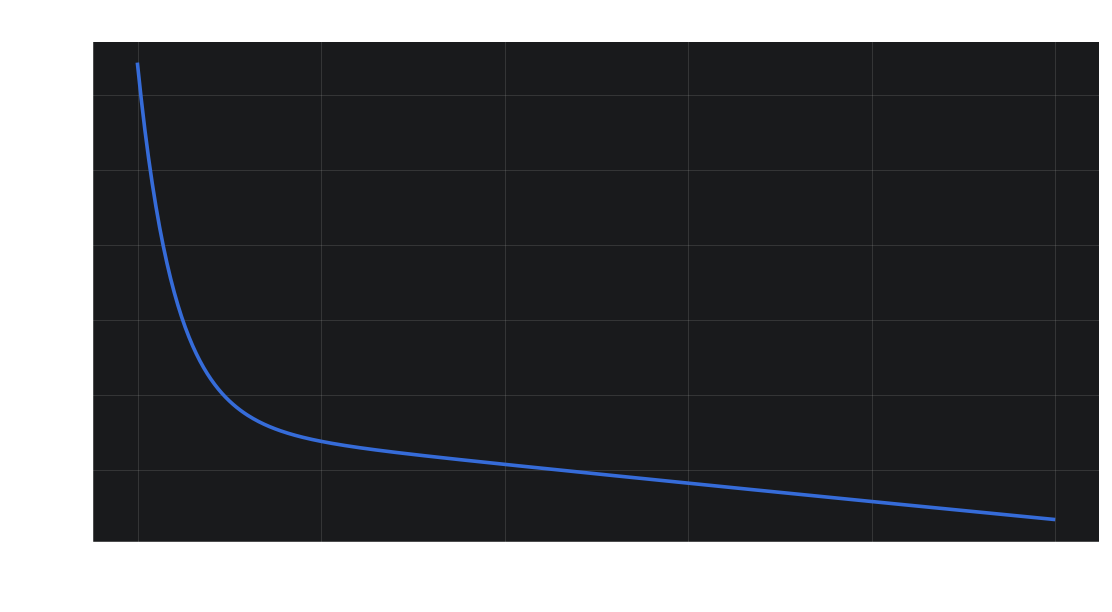

In [83]:
#plotting training cost over iterations
plt.figure(figsize=(10, 5))
plt.plot(lr_model.costs, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Training Cost over Iterations')
plt.grid(True, alpha=0.2)
plt.show()